In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import random
import numpy as np
import copy
import matplotlib.pyplot as plt


import os
os.environ["CUDA_VISIBLE_DEVICES"]="3"

/gpu-data2/anonymous/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fcs = nn.ModuleList([nn.Linear(hidden_size, hidden_size) for _ in range(n_layers)])
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten the input for the fully connected layer
        x = self.fc1(x)
        x = self.relu(x)
        for layer in self.fcs:
            x = layer(x)
            x = self.relu(x)
        x = self.fc2(x)
        return x

class MaxoutLayer(nn.Module):
    def __init__(self, input_size, output_size, pool_size=2, aggregate='max'):
        super(MaxoutLayer, self).__init__()
        self.output_size = output_size
        self.pool_size = pool_size
        # Create two linear transformations for the maxout operation
        self.linear = nn.ModuleList([nn.Linear(input_size, output_size) for _ in range(pool_size)])

    def forward(self, x):
        # Apply each linear layer and stack the results
        maxout_layers = torch.stack([layer(x) for layer in self.linear], dim=2)  # Shape: (batch, output_size, pool_size)
        # Take the max across the pool_size dimension
        maxout_output = torch.max(maxout_layers, dim=2).values  # Shape: (batch, output_size)
        return maxout_output

class Maxout(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(Maxout, self).__init__()
        self.maxout1 = MaxoutLayer(input_size, hidden_size, pool_size=2)
        self.maxouts = nn.ModuleList([MaxoutLayer(hidden_size, hidden_size) for _ in range(n_layers)])
        self.output = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.maxout1(x)
        for layer in self.maxouts:
            x = layer(x)
        x = self.output(x)
        return x

class MorphologicalLayer(nn.Module):
    def __init__(self, input_size, output_size, bias=True, method='max', l=None, alpha=1, beta=0):
        super(MorphologicalLayer, self).__init__()
        self.method = method
        self.bias = bias

        self.w = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
        if bias:
            self.b = nn.Parameter(torch.randn(output_size))
            if method == 'max-plus-min' or method == 'dep':
                self.b2 = nn.Parameter(torch.randn(output_size))
        if method == 'dep':
            self.w2 = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
            if l == None:
                self.l = nn.Parameter(torch.rand(output_size))
            else:
                self.l = l + torch.zeros(output_size).to(device)

    def forward(self, x, dropout=None):
        x = x.unsqueeze(1) 
        if dropout:
            mask = torch.rand(self.w.size(0), self.w.size(1)) < dropout
            mask = mask.to(device)
        if self.method == 'max':
            x = x + self.w
            if self.bias:
                x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x, _ = torch.max(x, dim=2)  # Take max over the input dimension
        elif self.method == 'min':
            x = x + self.w
            if self.bias:
                x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x, _ = torch.min(x, dim=2)
        elif self.method == 'max-plus-min':
            max_w = self.w
            min_w = self.w
            if dropout:
                max_w = max_w - mask * 1e9
                min_w = min_w + mask * 1e9
            x_max = x + max_w
            x_min = x + min_w
            if self.bias:
                x_max = torch.cat([x_max, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
                x_min = torch.cat([x_min, self.b2.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x_max, _ = torch.max(x_max, dim=2)
            x_min, _ = torch.min(x_min, dim=2)
            x = x_max + x_min
        elif self.method == 'dep':
            x_max = x + self.w
            x_min = x + self.w2
            if self.bias:
                x_max = torch.cat([x_max, self.b.view(1,-1,1).repeat(x_max.size(0),1,1)], dim=2)
                x_min = torch.cat([x_min, self.b2.view(1,-1,1).repeat(x_min.size(0),1,1)], dim=2)
            x_max, _ = torch.max(x_max, dim=2)
            x_min, _ = torch.min(x_min, dim=2)
            l = self.l.view(1,-1)
            l = torch.clamp(l, 0, 1)
            x = l * x_max + (1-l) * x_min
        return x
    
class LinAct(nn.Module):
    def __init__(self, size, method="simple"):
        super(LinAct, self).__init__()
        self.size = size
        self.method = method
        if method == "simple":
            self.a = nn.Parameter(torch.randn(size) / 3.46)
            # self.a = nn.Parameter(torch.rand(size)-0.5)
        else:
            tmp = nn.Linear(size, size, bias = False).weight.detach()
            U, S, Vh = np.linalg.svd(tmp.cpu().numpy(), full_matrices=True)
            self.U = torch.tensor(U).to(device)
            self.V = torch.tensor(Vh).t().to(device)
            self.a = torch.zeros(size).to(device)
            self.a[:S.shape[0]] = torch.tensor(S)
            self.a = nn.Parameter(self.a)

    def forward(self, x):
        if self.method == "simple":
            x = x * self.a.view(1, -1).repeat(x.size(0), 1)
        else:
            Smat = torch.diag(self.a)
            tmp = self.U @ Smat @ self.V.t()
            x = torch.mm(x, tmp.t())
        return x
    
# class Repeater(nn.Module):
#     def __init__(self, r):
#         super(Repeater, self).__init__()
#         self.r = r
#     def forward(self, x):
#         x = x.repeat(1, self.r)
#         return x
    
class MPM(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MPM, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

class RMPM(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(RMPM, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = x + layer(x)
        x = self.morph_layer2(x)
        return x
    
class RMPM_Drop(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4, dropout=0.5):
        super(RMPM_Drop, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

        self.dropout = dropout

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        if self.training:
            x = self.morph_layer1(x, self.dropout)
        else:
            x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            if self.training:
                x = x + layer[1](layer[0](x, self.dropout))
            else:
                x = x + layer(x)
        if self.training:
            x = self.morph_layer2(x, self.dropout)
        else:
            x = self.morph_layer2(x)
        return x
    
class MPM_SVD(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MPM_SVD, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size, method='svd')
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size, method='svd')) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

class HybridMLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(HybridMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.morph_layer1 = MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min')
        self.layers = nn.ModuleList(
            [nn.Sequential(nn.Linear(hidden_size, hidden_size), 
                           MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min'))
             for _ in range(n_layers)]
            )
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.fc1(x)
        x = self.morph_layer1(x)
        for layer in self.layers:
            x = layer(x)
        x = self.fc2(x)
        return x
    
class MP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max', alpha=0, beta=1)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max', alpha=3, beta=5)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max', alpha=3, beta=5)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x
    
class Act_MP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(Act_MP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max', alpha=0, beta=1)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max', alpha=3, beta=5), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max', alpha=3, beta=5)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x
    
class DEP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4, l=None):
        super(DEP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, bias=False, method='dep', l=l, alpha=0)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, bias=False, method='dep', l=l, alpha=1)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, bias=False, method='dep', l=l, alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x
    
class Act_DEP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4, l=None):
        super(Act_DEP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, bias=False, method='dep', l=l, alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, bias=False, method='dep', l=l, alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, bias = False, method='dep', l=l, alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x
    
class MorphConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=True, method="max-plus-min", alpha=1.0):
        super(MorphConv2d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.bias = bias
        self.method = method
        self.alpha = alpha

        self.weight = nn.Parameter(
            torch.normal(mean=0.0, std=alpha, size=(out_channels, in_channels, kernel_size[0], kernel_size[1]))
        )
        if bias:
            self.b = nn.Parameter(torch.normal(mean=0.0, std=1.0, size=(out_channels, )))
            self.b2 = nn.Parameter(torch.normal(mean=0.0, std=1.0, size=(out_channels, )))

    def forward(self, x):
        # Max morphological operation
        x_max = torch.exp(x)
        w_max = torch.exp(self.weight)
        if self.bias:
            b_max = torch.exp(self.b)
            x_max = F.conv2d(x_max, w_max, b_max, stride=self.stride, padding=self.padding)
        else:
            x_max = F.conv2d(x_max, w_max, stride=self.stride, padding=self.padding)
        x_max = torch.log(x_max)

        # Min morphological operation
        x_min = torch.exp(-x)
        w_min = torch.exp(-self.weight)
        if self.bias:
            b_min = torch.exp(-self.b2)
            x_min = F.conv2d(x_min, w_min, b_min, stride=self.stride, padding=self.padding)
        else:
            x_min = F.conv2d(x_min, w_min, stride=self.stride, padding=self.padding)
        x_min = -torch.log(x_min)

        # Aggregation of max and min operations
        if self.method == "max":
            x_out = x_max
        elif self.method == "min":
            x_out = x_min
        else:
            x_out = x_max + x_min

        return x_out
    
class ConvLinAct(nn.Module):
    def __init__(self, channels, method="simple"):
        super(ConvLinAct, self).__init__()
        self.method = method

        if method == 'simple':
            # self.a = nn.Parameter(torch.randn(channels, size, size)/3.46)
            # self.a = nn.Parameter(torch.rand(channels)-0.5)
            self.a = nn.Parameter(torch.randn(3, 3, channels))
        else:
            tmp = nn.Conv2d(channels, channels, 3, bias = False).weight.data.detach()
            tmp = torch.transpose(tmp, 0, 2)
            tmp = torch.transpose(tmp, 1, 3)
            U, S, Vh = np.linalg.svd(tmp.cpu().numpy(), full_matrices=True)
            self.U = torch.tensor(U).to(device)
            self.Vh = torch.tensor(Vh).to(device)
            self.a = torch.zeros(3, 3, channels).to(device)
            self.a[:, :, :S.shape[2]] = torch.tensor(S)
            self.a = nn.Parameter(self.a)
    def forward(self, x):
        if self.method == 'simple':
            # x = x * self.a.unsqueeze(-1).unsqueeze(-1).unsqueeze(0).repeat(x.size(0), 1, x.size(2), x.size(3))
            tmp = torch.diag_embed(self.a)
            tmp = torch.transpose(tmp, 0, 2)
            tmp = torch.transpose(tmp, 1, 3)
            x = nn.functional.conv2d(x, tmp, padding=1)
        else:
            tmp = self.U @ (self.a.unsqueeze(-1) * self.Vh)
            tmp = torch.transpose(tmp, 0, 2)
            tmp = torch.transpose(tmp, 1, 3)
            x = nn.functional.conv2d(x, tmp, padding=1)
        return x
    
class MPM_LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super(MPM_LeNet5, self).__init__()
                  
        self.conv1 = MorphConv2d(in_channels=1, out_channels=6, kernel_size=(5,5), padding = 1, method='max-plus-min', alpha=0.001)
        self.linact1 = ConvLinAct(6, method="simple")
        self.conv2 = MorphConv2d(in_channels=6, out_channels=16, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact2 = ConvLinAct(16, method="simple")
        self.conv3 = MorphConv2d(in_channels=16, out_channels=120, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact3 = ConvLinAct(120, method="simple")
        self.maxpool = nn.MaxPool2d(kernel_size=2)

        self.morph_layer1 = MorphologicalLayer(input_size=120, output_size=84, bias=True, method='max-plus-min')
        self.linact4 = LinAct(84)
        self.morph_layer2 = MorphologicalLayer(input_size=84, output_size=n_classes, bias=True, method='max-plus-min')

    def forward(self, x):
        x = self.conv1(x)
        x = self.linact1(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.linact2(x)
        x = self.maxpool(x)
        x = self.conv3(x)
        x = self.linact3(x)
        x = self.maxpool(x)

        x = torch.flatten(x, 1)
        
        x = self.morph_layer1(x)
        x = self.linact4(x)
        x = self.morph_layer2(x)
        return x

class MPM_SVD_LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super(MPM_SVD_LeNet5, self).__init__()
                  
        self.conv1 = MorphConv2d(in_channels=1, out_channels=6, kernel_size=(5,5), padding = 1, method='max-plus-min', alpha=0.001)
        self.linact1 = ConvLinAct(6, method="svd")
        self.conv2 = MorphConv2d(in_channels=6, out_channels=16, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact2 = ConvLinAct(16, method="svd")
        self.conv3 = MorphConv2d(in_channels=16, out_channels=120, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact3 = ConvLinAct(120, method="svd")
        self.maxpool = nn.MaxPool2d(kernel_size=2)

        self.morph_layer1 = MorphologicalLayer(input_size=120, output_size=84, bias=True, method='max-plus-min')
        self.linact4 = LinAct(84, method="svd")
        self.morph_layer2 = MorphologicalLayer(input_size=84, output_size=n_classes, bias=True, method='max-plus-min')

    def forward(self, x):
        x = self.conv1(x)
        x = self.linact1(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.linact2(x)
        x = self.maxpool(x)
        x = self.conv3(x)
        x = self.linact3(x)
        x = self.maxpool(x)

        x = torch.flatten(x, 1)
        
        x = self.morph_layer1(x)
        x = self.linact4(x)
        x = self.morph_layer2(x)
        return x

class LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super(LeNet5, self).__init__()
                  
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding = 1)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding = 1)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, padding = 1)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2)

        self.layer1 = nn.Linear(120, 84)
        self.layer2 = nn.Linear(84, n_classes, bias=False)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = torch.flatten(x, 1)
        
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x
    

In [5]:
def train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50, return_list=False):
    # Training and validation loop
    best_val_accuracy = 0.0
    best_model = None

    train_list = []
    val_list = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        train_list.append(train_accuracy)
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_list.append(val_accuracy)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {val_accuracy:.2f}%")

        # Save best model based on validation accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model = copy.deepcopy(model)

    if return_list:
        return best_model, train_list, val_list
    else:
        return best_model

def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy on the test set: {accuracy:.2f}%')

In [6]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [69]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698


Epoch [1/50], Loss: 0.3573, Train Accuracy: 93.91%, Validation Accuracy: 93.97%
Epoch [2/50], Loss: 0.1349, Train Accuracy: 96.51%, Validation Accuracy: 95.96%
Epoch [3/50], Loss: 0.0143, Train Accuracy: 96.91%, Validation Accuracy: 96.01%
Epoch [4/50], Loss: 0.0514, Train Accuracy: 96.32%, Validation Accuracy: 95.46%
Epoch [5/50], Loss: 0.1825, Train Accuracy: 97.43%, Validation Accuracy: 96.58%
Epoch [6/50], Loss: 0.0640, Train Accuracy: 97.88%, Validation Accuracy: 96.97%
Epoch [7/50], Loss: 0.1243, Train Accuracy: 97.51%, Validation Accuracy: 96.10%
Epoch [8/50], Loss: 0.2064, Train Accuracy: 97.96%, Validation Accuracy: 96.74%
Epoch [9/50], Loss: 0.0599, Train Accuracy: 97.00%, Validation Accuracy: 95.64%
Epoch [10/50], Loss: 0.0121, Train Accuracy: 98.29%, Validation Accuracy: 97.09%
Epoch [11/50], Loss: 0.0505, Train Accuracy: 98.48%, Validation Accuracy: 97.22%
Epoch [12/50], Loss: 0.0721, Train Accuracy: 98.82%, Validation Accuracy: 97.33%
Epoch [13/50], Loss: 0.0156, Train Ac

In [70]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.96%


In [71]:
# Initialize model, loss function, and optimizer
model = MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698
Epoch [1/50], Loss: 2.2790, Train Accuracy: 13.76%, Validation Accuracy: 14.29%
Epoch [2/50], Loss: 2.1771, Train Accuracy: 25.67%, Validation Accuracy: 26.25%
Epoch [3/50], Loss: 2.2109, Train Accuracy: 27.20%, Validation Accuracy: 27.64%
Epoch [4/50], Loss: 2.1607, Train Accuracy: 24.44%, Validation Accuracy: 24.32%
Epoch [5/50], Loss: 2.1289, Train Accuracy: 27.36%, Validation Accuracy: 27.84%
Epoch [6/50], Loss: 2.1125, Train Accuracy: 27.16%, Validation Accuracy: 27.59%
Epoch [7/50], Loss: 2.0711, Train Accuracy: 27.87%, Validation Accuracy: 28.27%
Epoch [8/50], Loss: 2.0779, Train Accuracy: 27.88%, Validation Accuracy: 28.27%
Epoch [9/50], Loss: 2.0772, Train Accuracy: 28.25%, Validation Accuracy: 28.67%
Epoch [10/50], Loss: 2.2205, Train Accuracy: 28.11%, Validation Accuracy: 28.57%
Epoch [11/50], Loss: 2.0942, Train Accuracy: 25.68%, Validation Accuracy: 25.62%
Epoch [12/50], Loss: 2.0848, Train Accuracy: 30.62%, Validation Accuracy: 30.94%
Ep

In [72]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 31.86%


In [73]:
# Initialize model, loss function, and optimizer
model = DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932106
Epoch [1/50], Loss: 2.1547, Train Accuracy: 28.52%, Validation Accuracy: 29.27%
Epoch [2/50], Loss: 1.9636, Train Accuracy: 42.10%, Validation Accuracy: 42.46%
Epoch [3/50], Loss: 1.8348, Train Accuracy: 48.26%, Validation Accuracy: 48.33%
Epoch [4/50], Loss: 1.8729, Train Accuracy: 49.26%, Validation Accuracy: 49.26%
Epoch [5/50], Loss: 1.7436, Train Accuracy: 52.17%, Validation Accuracy: 51.88%
Epoch [6/50], Loss: 1.6558, Train Accuracy: 52.29%, Validation Accuracy: 52.66%
Epoch [7/50], Loss: 1.6904, Train Accuracy: 57.74%, Validation Accuracy: 57.67%
Epoch [8/50], Loss: 1.7150, Train Accuracy: 59.35%, Validation Accuracy: 59.52%
Epoch [9/50], Loss: 1.6539, Train Accuracy: 60.58%, Validation Accuracy: 60.60%
Epoch [10/50], Loss: 1.5916, Train Accuracy: 62.00%, Validation Accuracy: 61.75%
Epoch [11/50], Loss: 1.5296, Train Accuracy: 62.36%, Validation Accuracy: 62.11%
Epoch [12/50], Loss: 1.6276, Train Accuracy: 62.37%, Validation Accuracy: 62.66%
Ep

In [74]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 79.31%


In [12]:
# Initialize model, loss function, and optimizer
model = DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 930816
Epoch [1/50], Loss: 2.2034, Train Accuracy: 39.65%, Validation Accuracy: 39.33%
Epoch [2/50], Loss: 2.1109, Train Accuracy: 53.81%, Validation Accuracy: 53.62%
Epoch [3/50], Loss: 1.9549, Train Accuracy: 58.11%, Validation Accuracy: 58.63%
Epoch [4/50], Loss: 1.9375, Train Accuracy: 63.85%, Validation Accuracy: 64.24%
Epoch [5/50], Loss: 1.8845, Train Accuracy: 66.85%, Validation Accuracy: 66.85%
Epoch [6/50], Loss: 1.9229, Train Accuracy: 65.53%, Validation Accuracy: 65.91%
Epoch [7/50], Loss: 1.8711, Train Accuracy: 66.71%, Validation Accuracy: 67.33%
Epoch [8/50], Loss: 1.9115, Train Accuracy: 71.74%, Validation Accuracy: 72.08%
Epoch [9/50], Loss: 1.8753, Train Accuracy: 71.07%, Validation Accuracy: 71.32%
Epoch [10/50], Loss: 1.8765, Train Accuracy: 70.99%, Validation Accuracy: 70.90%
Epoch [11/50], Loss: 1.8515, Train Accuracy: 73.74%, Validation Accuracy: 74.02%
Epoch [12/50], Loss: 1.8547, Train Accuracy: 75.91%, Validation Accuracy: 76.21%
Ep

In [13]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 79.10%


In [75]:
# Initialize model, loss function, and optimizer
model = Act_MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 467978


Epoch [1/50], Loss: 2.3087, Train Accuracy: 11.19%, Validation Accuracy: 11.43%
Epoch [2/50], Loss: 2.1086, Train Accuracy: 26.84%, Validation Accuracy: 26.55%
Epoch [3/50], Loss: 1.6062, Train Accuracy: 36.15%, Validation Accuracy: 35.74%
Epoch [4/50], Loss: 1.7100, Train Accuracy: 36.06%, Validation Accuracy: 35.63%
Epoch [5/50], Loss: 1.5951, Train Accuracy: 40.54%, Validation Accuracy: 40.41%
Epoch [6/50], Loss: 1.5155, Train Accuracy: 43.47%, Validation Accuracy: 43.46%
Epoch [7/50], Loss: 1.4479, Train Accuracy: 46.49%, Validation Accuracy: 46.07%
Epoch [8/50], Loss: 1.3981, Train Accuracy: 50.25%, Validation Accuracy: 49.40%
Epoch [9/50], Loss: 1.1914, Train Accuracy: 51.68%, Validation Accuracy: 50.59%
Epoch [10/50], Loss: 1.2294, Train Accuracy: 53.51%, Validation Accuracy: 52.64%
Epoch [11/50], Loss: 1.1181, Train Accuracy: 51.91%, Validation Accuracy: 50.92%
Epoch [12/50], Loss: 1.3400, Train Accuracy: 56.79%, Validation Accuracy: 55.98%
Epoch [13/50], Loss: 1.2080, Train Ac

In [76]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 71.00%


In [77]:
# Initialize model, loss function, and optimizer
model = Act_DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 933386
Epoch [1/50], Loss: 2.2982, Train Accuracy: 11.19%, Validation Accuracy: 11.43%
Epoch [2/50], Loss: 2.0680, Train Accuracy: 28.01%, Validation Accuracy: 28.14%
Epoch [3/50], Loss: 1.7985, Train Accuracy: 41.86%, Validation Accuracy: 42.43%
Epoch [4/50], Loss: 1.6615, Train Accuracy: 49.98%, Validation Accuracy: 50.91%
Epoch [5/50], Loss: 1.4806, Train Accuracy: 54.47%, Validation Accuracy: 55.28%
Epoch [6/50], Loss: 1.3254, Train Accuracy: 56.74%, Validation Accuracy: 57.34%
Epoch [7/50], Loss: 1.2948, Train Accuracy: 58.80%, Validation Accuracy: 59.29%
Epoch [8/50], Loss: 1.3458, Train Accuracy: 60.96%, Validation Accuracy: 61.65%
Epoch [9/50], Loss: 1.2362, Train Accuracy: 63.96%, Validation Accuracy: 64.65%
Epoch [10/50], Loss: 1.3906, Train Accuracy: 65.07%, Validation Accuracy: 65.51%
Epoch [11/50], Loss: 1.0959, Train Accuracy: 66.11%, Validation Accuracy: 66.51%
Epoch [12/50], Loss: 1.2009, Train Accuracy: 68.15%, Validation Accuracy: 68.91%
Ep

In [78]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 83.40%


In [79]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=3/4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096


Epoch [1/50], Loss: 2.2929, Train Accuracy: 11.19%, Validation Accuracy: 11.43%
Epoch [2/50], Loss: 1.8977, Train Accuracy: 39.03%, Validation Accuracy: 38.67%
Epoch [3/50], Loss: 1.3806, Train Accuracy: 64.36%, Validation Accuracy: 63.56%
Epoch [4/50], Loss: 1.1630, Train Accuracy: 74.81%, Validation Accuracy: 74.70%
Epoch [5/50], Loss: 0.6662, Train Accuracy: 80.58%, Validation Accuracy: 80.52%
Epoch [6/50], Loss: 0.8220, Train Accuracy: 83.29%, Validation Accuracy: 83.15%
Epoch [7/50], Loss: 0.6218, Train Accuracy: 84.70%, Validation Accuracy: 84.47%
Epoch [8/50], Loss: 0.5557, Train Accuracy: 85.78%, Validation Accuracy: 85.77%
Epoch [9/50], Loss: 0.5486, Train Accuracy: 86.56%, Validation Accuracy: 86.05%
Epoch [10/50], Loss: 0.4418, Train Accuracy: 87.20%, Validation Accuracy: 86.90%
Epoch [11/50], Loss: 0.4632, Train Accuracy: 87.84%, Validation Accuracy: 87.40%
Epoch [12/50], Loss: 0.5169, Train Accuracy: 88.25%, Validation Accuracy: 87.82%
Epoch [13/50], Loss: 0.3621, Train Ac

In [80]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 91.54%


In [81]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096


Epoch [1/50], Loss: 2.1188, Train Accuracy: 56.01%, Validation Accuracy: 55.78%
Epoch [2/50], Loss: 1.0463, Train Accuracy: 79.74%, Validation Accuracy: 79.56%
Epoch [3/50], Loss: 0.6168, Train Accuracy: 86.05%, Validation Accuracy: 85.75%
Epoch [4/50], Loss: 0.5866, Train Accuracy: 88.72%, Validation Accuracy: 88.68%
Epoch [5/50], Loss: 0.6970, Train Accuracy: 90.44%, Validation Accuracy: 90.08%
Epoch [6/50], Loss: 0.2609, Train Accuracy: 91.59%, Validation Accuracy: 91.04%
Epoch [7/50], Loss: 0.4277, Train Accuracy: 92.50%, Validation Accuracy: 91.65%
Epoch [8/50], Loss: 0.1580, Train Accuracy: 93.19%, Validation Accuracy: 91.86%
Epoch [9/50], Loss: 0.1677, Train Accuracy: 93.74%, Validation Accuracy: 92.40%
Epoch [10/50], Loss: 0.2555, Train Accuracy: 94.28%, Validation Accuracy: 93.00%
Epoch [11/50], Loss: 0.1861, Train Accuracy: 94.62%, Validation Accuracy: 93.20%
Epoch [12/50], Loss: 0.1785, Train Accuracy: 95.01%, Validation Accuracy: 93.40%
Epoch [13/50], Loss: 0.1369, Train Ac

In [82]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 94.11%


In [83]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268


Epoch [1/50], Loss: 0.8790, Train Accuracy: 82.93%, Validation Accuracy: 83.17%
Epoch [2/50], Loss: 0.4433, Train Accuracy: 90.21%, Validation Accuracy: 89.97%
Epoch [3/50], Loss: 0.4677, Train Accuracy: 92.40%, Validation Accuracy: 91.73%
Epoch [4/50], Loss: 0.2294, Train Accuracy: 93.65%, Validation Accuracy: 92.73%
Epoch [5/50], Loss: 0.2361, Train Accuracy: 94.45%, Validation Accuracy: 93.18%
Epoch [6/50], Loss: 0.1189, Train Accuracy: 95.10%, Validation Accuracy: 93.52%
Epoch [7/50], Loss: 0.1421, Train Accuracy: 95.74%, Validation Accuracy: 93.93%
Epoch [8/50], Loss: 0.1473, Train Accuracy: 96.01%, Validation Accuracy: 94.03%
Epoch [9/50], Loss: 0.1194, Train Accuracy: 96.47%, Validation Accuracy: 94.26%
Epoch [10/50], Loss: 0.1581, Train Accuracy: 96.86%, Validation Accuracy: 94.45%
Epoch [11/50], Loss: 0.2110, Train Accuracy: 97.03%, Validation Accuracy: 94.64%
Epoch [12/50], Loss: 0.1403, Train Accuracy: 97.29%, Validation Accuracy: 94.65%
Epoch [13/50], Loss: 0.1684, Train Ac

In [84]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 94.73%


In [85]:
# Initialize model, loss function, and optimizer
model = RMPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268


Epoch [1/50], Loss: 0.5510, Train Accuracy: 88.28%, Validation Accuracy: 88.65%
Epoch [2/50], Loss: 0.2864, Train Accuracy: 92.25%, Validation Accuracy: 91.92%
Epoch [3/50], Loss: 0.3707, Train Accuracy: 94.08%, Validation Accuracy: 93.16%
Epoch [4/50], Loss: 0.1230, Train Accuracy: 95.28%, Validation Accuracy: 94.02%
Epoch [5/50], Loss: 0.2898, Train Accuracy: 96.03%, Validation Accuracy: 94.47%
Epoch [6/50], Loss: 0.1880, Train Accuracy: 96.76%, Validation Accuracy: 94.77%
Epoch [7/50], Loss: 0.1042, Train Accuracy: 97.31%, Validation Accuracy: 94.98%
Epoch [8/50], Loss: 0.0744, Train Accuracy: 97.61%, Validation Accuracy: 95.16%
Epoch [9/50], Loss: 0.0581, Train Accuracy: 98.08%, Validation Accuracy: 95.33%
Epoch [10/50], Loss: 0.1320, Train Accuracy: 98.30%, Validation Accuracy: 95.22%
Epoch [11/50], Loss: 0.0324, Train Accuracy: 98.59%, Validation Accuracy: 95.43%
Epoch [12/50], Loss: 0.0476, Train Accuracy: 98.83%, Validation Accuracy: 95.38%
Epoch [13/50], Loss: 0.0796, Train Ac

In [86]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 95.22%


In [8]:
# Initialize model, loss function, and optimizer
model = RMPM_Drop(dropout=0.3).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=200)

Total number of parameters: 469268
Epoch [1/200], Loss: 1.8795, Train Accuracy: 74.01%, Validation Accuracy: 73.83%
Epoch [2/200], Loss: 1.0596, Train Accuracy: 84.58%, Validation Accuracy: 84.34%
Epoch [3/200], Loss: 0.8056, Train Accuracy: 87.82%, Validation Accuracy: 87.27%
Epoch [4/200], Loss: 0.4991, Train Accuracy: 89.55%, Validation Accuracy: 89.11%
Epoch [5/200], Loss: 0.5167, Train Accuracy: 90.39%, Validation Accuracy: 90.09%
Epoch [6/200], Loss: 0.3931, Train Accuracy: 91.32%, Validation Accuracy: 90.84%
Epoch [7/200], Loss: 0.5646, Train Accuracy: 92.03%, Validation Accuracy: 91.51%
Epoch [8/200], Loss: 0.4591, Train Accuracy: 92.57%, Validation Accuracy: 91.97%
Epoch [9/200], Loss: 0.2375, Train Accuracy: 93.20%, Validation Accuracy: 92.38%
Epoch [10/200], Loss: 0.1631, Train Accuracy: 93.59%, Validation Accuracy: 92.82%
Epoch [11/200], Loss: 0.3326, Train Accuracy: 94.07%, Validation Accuracy: 93.12%
Epoch [12/200], Loss: 0.3006, Train Accuracy: 94.33%, Validation Accurac

In [9]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.33%


In [87]:
# Initialize model, loss function, and optimizer
model = MPM_SVD().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268


Epoch [1/50], Loss: 0.4158, Train Accuracy: 90.20%, Validation Accuracy: 90.32%
Epoch [2/50], Loss: 0.3992, Train Accuracy: 94.19%, Validation Accuracy: 93.49%
Epoch [3/50], Loss: 0.2148, Train Accuracy: 95.71%, Validation Accuracy: 94.32%
Epoch [4/50], Loss: 0.1543, Train Accuracy: 97.04%, Validation Accuracy: 95.03%
Epoch [5/50], Loss: 0.1505, Train Accuracy: 97.62%, Validation Accuracy: 95.30%
Epoch [6/50], Loss: 0.0848, Train Accuracy: 98.14%, Validation Accuracy: 95.33%
Epoch [7/50], Loss: 0.0386, Train Accuracy: 98.36%, Validation Accuracy: 95.47%
Epoch [8/50], Loss: 0.0509, Train Accuracy: 98.86%, Validation Accuracy: 95.66%
Epoch [9/50], Loss: 0.0642, Train Accuracy: 99.07%, Validation Accuracy: 95.72%
Epoch [10/50], Loss: 0.0262, Train Accuracy: 99.23%, Validation Accuracy: 95.63%
Epoch [11/50], Loss: 0.1224, Train Accuracy: 99.49%, Validation Accuracy: 96.03%
Epoch [12/50], Loss: 0.0575, Train Accuracy: 99.42%, Validation Accuracy: 95.84%
Epoch [13/50], Loss: 0.0134, Train Ac

In [88]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 96.13%


In [89]:
# Initialize model, loss function, and optimizer
model = LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 61696


Epoch [1/50], Loss: 0.2150, Train Accuracy: 97.51%, Validation Accuracy: 97.04%
Epoch [2/50], Loss: 0.0138, Train Accuracy: 97.95%, Validation Accuracy: 97.61%
Epoch [3/50], Loss: 0.2223, Train Accuracy: 98.88%, Validation Accuracy: 98.13%
Epoch [4/50], Loss: 0.0241, Train Accuracy: 99.03%, Validation Accuracy: 98.33%
Epoch [5/50], Loss: 0.0283, Train Accuracy: 99.14%, Validation Accuracy: 98.27%
Epoch [6/50], Loss: 0.0327, Train Accuracy: 99.10%, Validation Accuracy: 98.36%
Epoch [7/50], Loss: 0.0355, Train Accuracy: 99.53%, Validation Accuracy: 98.67%
Epoch [8/50], Loss: 0.0018, Train Accuracy: 99.41%, Validation Accuracy: 98.54%
Epoch [9/50], Loss: 0.0066, Train Accuracy: 99.63%, Validation Accuracy: 98.79%
Epoch [10/50], Loss: 0.0008, Train Accuracy: 99.65%, Validation Accuracy: 98.74%
Epoch [11/50], Loss: 0.0055, Train Accuracy: 99.60%, Validation Accuracy: 98.63%
Epoch [12/50], Loss: 0.0006, Train Accuracy: 99.71%, Validation Accuracy: 98.75%
Epoch [13/50], Loss: 0.0046, Train Ac

In [90]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 99.07%


In [91]:
# Initialize model, loss function, and optimizer
model = MPM_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304


Epoch [1/50], Loss: 1.6439, Train Accuracy: 43.02%, Validation Accuracy: 42.84%
Epoch [2/50], Loss: 1.2652, Train Accuracy: 64.01%, Validation Accuracy: 64.34%
Epoch [3/50], Loss: 1.0994, Train Accuracy: 73.64%, Validation Accuracy: 73.99%
Epoch [4/50], Loss: 0.8983, Train Accuracy: 78.86%, Validation Accuracy: 79.18%
Epoch [5/50], Loss: 0.3995, Train Accuracy: 81.47%, Validation Accuracy: 81.66%
Epoch [6/50], Loss: 0.4982, Train Accuracy: 83.75%, Validation Accuracy: 84.03%
Epoch [7/50], Loss: 0.2974, Train Accuracy: 85.34%, Validation Accuracy: 85.62%
Epoch [8/50], Loss: 0.5108, Train Accuracy: 86.70%, Validation Accuracy: 86.85%
Epoch [9/50], Loss: 0.3585, Train Accuracy: 88.24%, Validation Accuracy: 88.08%
Epoch [10/50], Loss: 0.3502, Train Accuracy: 89.05%, Validation Accuracy: 88.92%
Epoch [11/50], Loss: 0.3732, Train Accuracy: 90.05%, Validation Accuracy: 89.95%
Epoch [12/50], Loss: 0.2999, Train Accuracy: 90.96%, Validation Accuracy: 90.85%
Epoch [13/50], Loss: 0.3488, Train Ac

In [92]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 96.76%


In [93]:
# Initialize model, loss function, and optimizer
model = MPM_SVD_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304


Epoch [1/50], Loss: 0.8111, Train Accuracy: 73.50%, Validation Accuracy: 73.87%
Epoch [2/50], Loss: 0.5852, Train Accuracy: 81.86%, Validation Accuracy: 81.81%
Epoch [3/50], Loss: 0.4317, Train Accuracy: 85.06%, Validation Accuracy: 85.42%
Epoch [4/50], Loss: 0.3880, Train Accuracy: 87.40%, Validation Accuracy: 87.33%
Epoch [5/50], Loss: 0.5486, Train Accuracy: 88.43%, Validation Accuracy: 88.34%
Epoch [6/50], Loss: 0.4199, Train Accuracy: 89.89%, Validation Accuracy: 89.85%
Epoch [7/50], Loss: 0.2513, Train Accuracy: 90.92%, Validation Accuracy: 90.90%
Epoch [8/50], Loss: 0.2397, Train Accuracy: 90.81%, Validation Accuracy: 90.89%
Epoch [9/50], Loss: 0.3197, Train Accuracy: 92.08%, Validation Accuracy: 92.06%
Epoch [10/50], Loss: 0.2391, Train Accuracy: 91.62%, Validation Accuracy: 91.85%
Epoch [11/50], Loss: 0.2251, Train Accuracy: 92.89%, Validation Accuracy: 92.73%
Epoch [12/50], Loss: 0.4394, Train Accuracy: 93.47%, Validation Accuracy: 93.28%
Epoch [13/50], Loss: 0.1654, Train Ac

In [94]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 96.94%


In [10]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [96]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698


Epoch [1/50], Loss: 0.4222, Train Accuracy: 84.74%, Validation Accuracy: 83.33%
Epoch [2/50], Loss: 0.5033, Train Accuracy: 86.14%, Validation Accuracy: 84.78%
Epoch [3/50], Loss: 0.5499, Train Accuracy: 86.91%, Validation Accuracy: 85.04%
Epoch [4/50], Loss: 0.3192, Train Accuracy: 88.38%, Validation Accuracy: 86.34%
Epoch [5/50], Loss: 0.3278, Train Accuracy: 88.34%, Validation Accuracy: 86.45%
Epoch [6/50], Loss: 0.3705, Train Accuracy: 89.29%, Validation Accuracy: 87.17%
Epoch [7/50], Loss: 0.1708, Train Accuracy: 90.67%, Validation Accuracy: 88.21%
Epoch [8/50], Loss: 0.1970, Train Accuracy: 90.22%, Validation Accuracy: 87.43%
Epoch [9/50], Loss: 0.2933, Train Accuracy: 91.25%, Validation Accuracy: 88.41%
Epoch [10/50], Loss: 0.4374, Train Accuracy: 91.01%, Validation Accuracy: 87.67%
Epoch [11/50], Loss: 0.3775, Train Accuracy: 90.30%, Validation Accuracy: 87.21%
Epoch [12/50], Loss: 0.1899, Train Accuracy: 92.27%, Validation Accuracy: 88.80%
Epoch [13/50], Loss: 0.2570, Train Ac

In [97]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 88.50%


In [98]:
# Initialize model, loss function, and optimizer
model = MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698
Epoch [1/50], Loss: 2.2612, Train Accuracy: 13.86%, Validation Accuracy: 14.18%
Epoch [2/50], Loss: 2.1583, Train Accuracy: 20.01%, Validation Accuracy: 19.73%
Epoch [3/50], Loss: 2.1046, Train Accuracy: 20.92%, Validation Accuracy: 21.39%
Epoch [4/50], Loss: 2.1231, Train Accuracy: 22.20%, Validation Accuracy: 21.68%
Epoch [5/50], Loss: 2.1710, Train Accuracy: 22.36%, Validation Accuracy: 22.18%
Epoch [6/50], Loss: 2.1458, Train Accuracy: 22.47%, Validation Accuracy: 22.05%
Epoch [7/50], Loss: 2.1289, Train Accuracy: 22.79%, Validation Accuracy: 22.63%
Epoch [8/50], Loss: 2.0597, Train Accuracy: 18.55%, Validation Accuracy: 18.59%
Epoch [9/50], Loss: 2.1558, Train Accuracy: 22.46%, Validation Accuracy: 22.57%
Epoch [10/50], Loss: 2.1082, Train Accuracy: 18.59%, Validation Accuracy: 18.63%
Epoch [11/50], Loss: 2.1448, Train Accuracy: 18.07%, Validation Accuracy: 18.69%
Epoch [12/50], Loss: 2.1035, Train Accuracy: 23.67%, Validation Accuracy: 23.79%
Ep

In [99]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 23.26%


In [100]:
# Initialize model, loss function, and optimizer
model = DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932106


Epoch [1/50], Loss: 2.1570, Train Accuracy: 33.50%, Validation Accuracy: 33.20%
Epoch [2/50], Loss: 1.9415, Train Accuracy: 33.56%, Validation Accuracy: 32.91%
Epoch [3/50], Loss: 1.8313, Train Accuracy: 40.59%, Validation Accuracy: 40.16%
Epoch [4/50], Loss: 1.8188, Train Accuracy: 48.78%, Validation Accuracy: 48.39%
Epoch [5/50], Loss: 1.7703, Train Accuracy: 49.38%, Validation Accuracy: 48.92%
Epoch [6/50], Loss: 1.7067, Train Accuracy: 51.06%, Validation Accuracy: 51.25%
Epoch [7/50], Loss: 1.7621, Train Accuracy: 50.05%, Validation Accuracy: 49.98%
Epoch [8/50], Loss: 1.7907, Train Accuracy: 55.30%, Validation Accuracy: 55.62%
Epoch [9/50], Loss: 1.7735, Train Accuracy: 57.28%, Validation Accuracy: 57.06%
Epoch [10/50], Loss: 1.8055, Train Accuracy: 57.65%, Validation Accuracy: 57.25%
Epoch [11/50], Loss: 1.6793, Train Accuracy: 59.17%, Validation Accuracy: 58.81%
Epoch [12/50], Loss: 1.6351, Train Accuracy: 58.49%, Validation Accuracy: 58.31%
Epoch [13/50], Loss: 1.6971, Train Ac

In [101]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 62.05%


In [17]:
# Initialize model, loss function, and optimizer
model = DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 930816
Epoch [1/50], Loss: 2.2264, Train Accuracy: 54.67%, Validation Accuracy: 54.44%
Epoch [2/50], Loss: 2.0473, Train Accuracy: 59.41%, Validation Accuracy: 60.13%
Epoch [3/50], Loss: 2.0116, Train Accuracy: 62.69%, Validation Accuracy: 63.94%
Epoch [4/50], Loss: 1.8996, Train Accuracy: 65.58%, Validation Accuracy: 66.65%
Epoch [5/50], Loss: 1.9402, Train Accuracy: 65.76%, Validation Accuracy: 66.61%
Epoch [6/50], Loss: 1.9033, Train Accuracy: 64.57%, Validation Accuracy: 65.63%
Epoch [7/50], Loss: 1.8592, Train Accuracy: 66.81%, Validation Accuracy: 67.93%
Epoch [8/50], Loss: 1.8842, Train Accuracy: 66.94%, Validation Accuracy: 67.72%
Epoch [9/50], Loss: 1.8438, Train Accuracy: 68.76%, Validation Accuracy: 69.35%
Epoch [10/50], Loss: 1.8246, Train Accuracy: 68.60%, Validation Accuracy: 69.53%
Epoch [11/50], Loss: 1.8931, Train Accuracy: 68.33%, Validation Accuracy: 68.85%
Epoch [12/50], Loss: 1.7897, Train Accuracy: 69.02%, Validation Accuracy: 69.77%
Ep

In [18]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 72.00%


In [102]:
# Initialize model, loss function, and optimizer
model = Act_MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 467978
Epoch [1/50], Loss: 2.3887, Train Accuracy: 9.98%, Validation Accuracy: 10.07%
Epoch [2/50], Loss: 2.2341, Train Accuracy: 23.35%, Validation Accuracy: 23.77%
Epoch [3/50], Loss: 2.1080, Train Accuracy: 22.31%, Validation Accuracy: 22.48%
Epoch [4/50], Loss: 2.0473, Train Accuracy: 15.09%, Validation Accuracy: 15.22%
Epoch [5/50], Loss: 1.8223, Train Accuracy: 20.91%, Validation Accuracy: 20.80%
Epoch [6/50], Loss: 1.9352, Train Accuracy: 21.18%, Validation Accuracy: 20.29%
Epoch [7/50], Loss: 1.7911, Train Accuracy: 33.75%, Validation Accuracy: 33.44%
Epoch [8/50], Loss: 1.9446, Train Accuracy: 32.62%, Validation Accuracy: 32.00%
Epoch [9/50], Loss: 1.8309, Train Accuracy: 35.12%, Validation Accuracy: 34.42%
Epoch [10/50], Loss: 1.7255, Train Accuracy: 34.24%, Validation Accuracy: 32.97%
Epoch [11/50], Loss: 1.6318, Train Accuracy: 33.44%, Validation Accuracy: 32.38%
Epoch [12/50], Loss: 1.7551, Train Accuracy: 30.19%, Validation Accuracy: 29.57%
Epo

In [103]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 35.11%


In [104]:
# Initialize model, loss function, and optimizer
model = Act_DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 933386
Epoch [1/50], Loss: 2.2733, Train Accuracy: 16.42%, Validation Accuracy: 16.71%
Epoch [2/50], Loss: 1.9391, Train Accuracy: 25.52%, Validation Accuracy: 25.77%
Epoch [3/50], Loss: 1.7216, Train Accuracy: 35.06%, Validation Accuracy: 35.44%
Epoch [4/50], Loss: 1.6599, Train Accuracy: 38.39%, Validation Accuracy: 38.67%
Epoch [5/50], Loss: 1.5601, Train Accuracy: 40.05%, Validation Accuracy: 40.20%
Epoch [6/50], Loss: 1.4834, Train Accuracy: 43.23%, Validation Accuracy: 42.88%
Epoch [7/50], Loss: 1.4248, Train Accuracy: 48.92%, Validation Accuracy: 47.61%
Epoch [8/50], Loss: 1.4383, Train Accuracy: 51.77%, Validation Accuracy: 50.59%
Epoch [9/50], Loss: 1.1491, Train Accuracy: 53.30%, Validation Accuracy: 52.24%
Epoch [10/50], Loss: 1.4207, Train Accuracy: 54.81%, Validation Accuracy: 53.82%
Epoch [11/50], Loss: 1.2197, Train Accuracy: 55.99%, Validation Accuracy: 55.38%
Epoch [12/50], Loss: 1.2502, Train Accuracy: 56.20%, Validation Accuracy: 55.38%
Ep

In [105]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 63.63%


In [106]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=3/4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096


Epoch [1/50], Loss: 2.2936, Train Accuracy: 10.08%, Validation Accuracy: 9.67%
Epoch [2/50], Loss: 1.9310, Train Accuracy: 33.69%, Validation Accuracy: 32.68%
Epoch [3/50], Loss: 1.3881, Train Accuracy: 59.75%, Validation Accuracy: 58.62%
Epoch [4/50], Loss: 1.1180, Train Accuracy: 63.99%, Validation Accuracy: 62.78%
Epoch [5/50], Loss: 0.8762, Train Accuracy: 66.12%, Validation Accuracy: 64.84%
Epoch [6/50], Loss: 1.0075, Train Accuracy: 67.94%, Validation Accuracy: 66.80%
Epoch [7/50], Loss: 0.8408, Train Accuracy: 70.10%, Validation Accuracy: 68.92%
Epoch [8/50], Loss: 0.6526, Train Accuracy: 71.73%, Validation Accuracy: 70.11%
Epoch [9/50], Loss: 0.6489, Train Accuracy: 72.91%, Validation Accuracy: 71.13%
Epoch [10/50], Loss: 0.6936, Train Accuracy: 73.60%, Validation Accuracy: 71.70%
Epoch [11/50], Loss: 0.7690, Train Accuracy: 74.28%, Validation Accuracy: 72.22%
Epoch [12/50], Loss: 0.7615, Train Accuracy: 74.61%, Validation Accuracy: 72.72%
Epoch [13/50], Loss: 0.8905, Train Acc

In [107]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 79.99%


In [108]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096


Epoch [1/50], Loss: 2.0881, Train Accuracy: 44.94%, Validation Accuracy: 44.38%
Epoch [2/50], Loss: 1.1098, Train Accuracy: 73.09%, Validation Accuracy: 71.54%
Epoch [3/50], Loss: 0.8188, Train Accuracy: 76.96%, Validation Accuracy: 75.20%
Epoch [4/50], Loss: 0.5933, Train Accuracy: 79.57%, Validation Accuracy: 77.54%
Epoch [5/50], Loss: 0.5220, Train Accuracy: 81.36%, Validation Accuracy: 79.09%
Epoch [6/50], Loss: 0.5570, Train Accuracy: 82.39%, Validation Accuracy: 79.76%
Epoch [7/50], Loss: 0.6755, Train Accuracy: 83.49%, Validation Accuracy: 80.73%
Epoch [8/50], Loss: 0.4493, Train Accuracy: 84.15%, Validation Accuracy: 80.90%
Epoch [9/50], Loss: 0.4544, Train Accuracy: 84.90%, Validation Accuracy: 81.38%
Epoch [10/50], Loss: 0.4039, Train Accuracy: 85.47%, Validation Accuracy: 81.51%
Epoch [11/50], Loss: 0.4862, Train Accuracy: 85.86%, Validation Accuracy: 81.73%
Epoch [12/50], Loss: 0.4322, Train Accuracy: 86.38%, Validation Accuracy: 81.72%
Epoch [13/50], Loss: 0.3057, Train Ac

In [109]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 82.36%


In [110]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.9433, Train Accuracy: 72.95%, Validation Accuracy: 71.48%
Epoch [2/50], Loss: 0.6403, Train Accuracy: 82.09%, Validation Accuracy: 79.53%
Epoch [3/50], Loss: 0.4865, Train Accuracy: 84.48%, Validation Accuracy: 80.88%
Epoch [4/50], Loss: 0.5010, Train Accuracy: 86.29%, Validation Accuracy: 81.78%
Epoch [5/50], Loss: 0.2379, Train Accuracy: 87.66%, Validation Accuracy: 82.37%
Epoch [6/50], Loss: 0.2016, Train Accuracy: 88.43%, Validation Accuracy: 82.47%
Epoch [7/50], Loss: 0.2009, Train Accuracy: 89.72%, Validation Accuracy: 82.80%
Epoch [8/50], Loss: 0.3802, Train Accuracy: 90.31%, Validation Accuracy: 83.05%
Epoch [9/50], Loss: 0.3353, Train Accuracy: 91.00%, Validation Accuracy: 83.12%
Epoch [10/50], Loss: 0.2608, Train Accuracy: 91.91%, Validation Accuracy: 83.15%
Epoch [11/50], Loss: 0.2028, Train Accuracy: 92.26%, Validation Accuracy: 82.94%
Epoch [12/50], Loss: 0.2772, Train Accuracy: 92.66%, Validation Accuracy: 83.21%
Ep

In [111]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 82.78%


In [112]:
# Initialize model, loss function, and optimizer
model = RMPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.6948, Train Accuracy: 80.17%, Validation Accuracy: 78.56%
Epoch [2/50], Loss: 0.4454, Train Accuracy: 84.55%, Validation Accuracy: 81.85%
Epoch [3/50], Loss: 0.3705, Train Accuracy: 87.32%, Validation Accuracy: 83.51%
Epoch [4/50], Loss: 0.4925, Train Accuracy: 88.68%, Validation Accuracy: 83.97%
Epoch [5/50], Loss: 0.3630, Train Accuracy: 90.25%, Validation Accuracy: 84.67%
Epoch [6/50], Loss: 0.2300, Train Accuracy: 91.47%, Validation Accuracy: 84.87%
Epoch [7/50], Loss: 0.3129, Train Accuracy: 92.28%, Validation Accuracy: 84.99%
Epoch [8/50], Loss: 0.2368, Train Accuracy: 93.48%, Validation Accuracy: 85.14%
Epoch [9/50], Loss: 0.1684, Train Accuracy: 94.01%, Validation Accuracy: 84.95%
Epoch [10/50], Loss: 0.2619, Train Accuracy: 94.66%, Validation Accuracy: 85.10%
Epoch [11/50], Loss: 0.2597, Train Accuracy: 95.33%, Validation Accuracy: 85.20%
Epoch [12/50], Loss: 0.1633, Train Accuracy: 95.61%, Validation Accuracy: 85.06%
Ep

In [113]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 84.52%


In [11]:
# Initialize model, loss function, and optimizer
model = RMPM_Drop(dropout=0.3).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=200)

Total number of parameters: 469268
Epoch [1/200], Loss: 1.7279, Train Accuracy: 62.85%, Validation Accuracy: 62.77%
Epoch [2/200], Loss: 1.2879, Train Accuracy: 72.88%, Validation Accuracy: 72.96%
Epoch [3/200], Loss: 1.0811, Train Accuracy: 76.87%, Validation Accuracy: 77.01%
Epoch [4/200], Loss: 0.9416, Train Accuracy: 78.97%, Validation Accuracy: 78.93%
Epoch [5/200], Loss: 0.7429, Train Accuracy: 80.47%, Validation Accuracy: 80.27%
Epoch [6/200], Loss: 0.8191, Train Accuracy: 81.56%, Validation Accuracy: 81.00%
Epoch [7/200], Loss: 0.5857, Train Accuracy: 81.96%, Validation Accuracy: 81.00%
Epoch [8/200], Loss: 0.8165, Train Accuracy: 82.71%, Validation Accuracy: 81.92%
Epoch [9/200], Loss: 0.7114, Train Accuracy: 83.26%, Validation Accuracy: 82.33%
Epoch [10/200], Loss: 0.5391, Train Accuracy: 83.87%, Validation Accuracy: 82.54%
Epoch [11/200], Loss: 0.6315, Train Accuracy: 84.20%, Validation Accuracy: 82.86%
Epoch [12/200], Loss: 0.6514, Train Accuracy: 84.45%, Validation Accurac

In [12]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 87.09%


In [114]:
# Initialize model, loss function, and optimizer
model = MPM_SVD().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.4549, Train Accuracy: 83.07%, Validation Accuracy: 80.97%
Epoch [2/50], Loss: 0.5419, Train Accuracy: 86.74%, Validation Accuracy: 82.91%
Epoch [3/50], Loss: 0.3157, Train Accuracy: 89.61%, Validation Accuracy: 84.42%
Epoch [4/50], Loss: 0.3053, Train Accuracy: 90.73%, Validation Accuracy: 84.81%
Epoch [5/50], Loss: 0.1942, Train Accuracy: 92.58%, Validation Accuracy: 85.02%
Epoch [6/50], Loss: 0.2961, Train Accuracy: 93.90%, Validation Accuracy: 85.23%
Epoch [7/50], Loss: 0.2111, Train Accuracy: 94.80%, Validation Accuracy: 85.35%
Epoch [8/50], Loss: 0.1638, Train Accuracy: 95.72%, Validation Accuracy: 85.29%
Epoch [9/50], Loss: 0.1120, Train Accuracy: 95.66%, Validation Accuracy: 85.01%
Epoch [10/50], Loss: 0.2254, Train Accuracy: 96.10%, Validation Accuracy: 84.58%
Epoch [11/50], Loss: 0.1335, Train Accuracy: 97.26%, Validation Accuracy: 85.07%
Epoch [12/50], Loss: 0.1425, Train Accuracy: 97.60%, Validation Accuracy: 84.91%
Ep

In [115]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 84.59%


In [116]:
# Initialize model, loss function, and optimizer
model = LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 61696


Epoch [1/50], Loss: 0.3413, Train Accuracy: 82.09%, Validation Accuracy: 81.17%
Epoch [2/50], Loss: 0.1483, Train Accuracy: 86.71%, Validation Accuracy: 85.85%
Epoch [3/50], Loss: 0.5457, Train Accuracy: 88.39%, Validation Accuracy: 87.38%
Epoch [4/50], Loss: 0.2446, Train Accuracy: 88.56%, Validation Accuracy: 87.59%
Epoch [5/50], Loss: 0.1634, Train Accuracy: 90.13%, Validation Accuracy: 88.89%
Epoch [6/50], Loss: 0.1987, Train Accuracy: 90.30%, Validation Accuracy: 88.93%
Epoch [7/50], Loss: 0.1543, Train Accuracy: 91.76%, Validation Accuracy: 89.63%
Epoch [8/50], Loss: 0.3008, Train Accuracy: 92.16%, Validation Accuracy: 89.83%
Epoch [9/50], Loss: 0.1867, Train Accuracy: 92.47%, Validation Accuracy: 89.94%
Epoch [10/50], Loss: 0.1371, Train Accuracy: 93.45%, Validation Accuracy: 90.67%
Epoch [11/50], Loss: 0.0891, Train Accuracy: 93.21%, Validation Accuracy: 90.04%
Epoch [12/50], Loss: 0.2548, Train Accuracy: 93.71%, Validation Accuracy: 90.32%
Epoch [13/50], Loss: 0.0597, Train Ac

In [117]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 90.24%


In [118]:
# Initialize model, loss function, and optimizer
model = MPM_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304


Epoch [1/50], Loss: 1.5263, Train Accuracy: 46.66%, Validation Accuracy: 45.76%
Epoch [2/50], Loss: 1.2721, Train Accuracy: 61.51%, Validation Accuracy: 61.09%
Epoch [3/50], Loss: 1.0491, Train Accuracy: 66.30%, Validation Accuracy: 65.66%
Epoch [4/50], Loss: 0.9404, Train Accuracy: 68.71%, Validation Accuracy: 68.14%
Epoch [5/50], Loss: 0.7683, Train Accuracy: 70.52%, Validation Accuracy: 69.69%
Epoch [6/50], Loss: 0.9587, Train Accuracy: 72.47%, Validation Accuracy: 71.45%
Epoch [7/50], Loss: 0.6963, Train Accuracy: 73.23%, Validation Accuracy: 72.11%
Epoch [8/50], Loss: 0.8043, Train Accuracy: 74.13%, Validation Accuracy: 73.09%
Epoch [9/50], Loss: 0.9409, Train Accuracy: 75.47%, Validation Accuracy: 74.49%
Epoch [10/50], Loss: 0.5834, Train Accuracy: 75.82%, Validation Accuracy: 74.63%
Epoch [11/50], Loss: 0.7536, Train Accuracy: 76.47%, Validation Accuracy: 74.89%
Epoch [12/50], Loss: 0.4994, Train Accuracy: 77.59%, Validation Accuracy: 75.87%
Epoch [13/50], Loss: 0.6572, Train Ac

In [119]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 83.04%


In [120]:
# Initialize model, loss function, and optimizer
model = MPM_SVD_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304
Epoch [1/50], Loss: 1.1344, Train Accuracy: 66.89%, Validation Accuracy: 66.47%
Epoch [2/50], Loss: 0.7336, Train Accuracy: 71.53%, Validation Accuracy: 70.62%
Epoch [3/50], Loss: 0.6619, Train Accuracy: 74.63%, Validation Accuracy: 73.46%
Epoch [4/50], Loss: 0.5681, Train Accuracy: 76.46%, Validation Accuracy: 75.34%
Epoch [5/50], Loss: 0.5587, Train Accuracy: 77.91%, Validation Accuracy: 76.48%
Epoch [6/50], Loss: 0.7828, Train Accuracy: 78.16%, Validation Accuracy: 77.23%
Epoch [7/50], Loss: 0.6093, Train Accuracy: 79.14%, Validation Accuracy: 77.81%
Epoch [8/50], Loss: 0.3965, Train Accuracy: 79.85%, Validation Accuracy: 78.68%
Epoch [9/50], Loss: 0.8323, Train Accuracy: 81.05%, Validation Accuracy: 79.54%
Epoch [10/50], Loss: 0.6513, Train Accuracy: 80.54%, Validation Accuracy: 79.06%
Epoch [11/50], Loss: 0.4836, Train Accuracy: 81.88%, Validation Accuracy: 80.20%
Epoch [12/50], Loss: 0.5758, Train Accuracy: 82.11%, Validation Accuracy: 80.26%
Epo

In [121]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 84.42%


In [7]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [8]:
# Initialize model, loss function, and optimizer
model = MLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, mlp_train_list, mlp_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 466698
Epoch [1/20], Loss: 2.0119, Train Accuracy: 46.68%, Validation Accuracy: 46.42%
Epoch [2/20], Loss: 1.0955, Train Accuracy: 65.38%, Validation Accuracy: 65.48%
Epoch [3/20], Loss: 0.7560, Train Accuracy: 76.95%, Validation Accuracy: 77.17%
Epoch [4/20], Loss: 0.6088, Train Accuracy: 82.35%, Validation Accuracy: 82.34%
Epoch [5/20], Loss: 0.4939, Train Accuracy: 85.01%, Validation Accuracy: 85.19%
Epoch [6/20], Loss: 0.4610, Train Accuracy: 86.84%, Validation Accuracy: 86.88%
Epoch [7/20], Loss: 0.3840, Train Accuracy: 88.77%, Validation Accuracy: 88.91%
Epoch [8/20], Loss: 0.3618, Train Accuracy: 90.05%, Validation Accuracy: 90.00%
Epoch [9/20], Loss: 0.3059, Train Accuracy: 90.49%, Validation Accuracy: 90.66%
Epoch [10/20], Loss: 0.3051, Train Accuracy: 90.90%, Validation Accuracy: 90.88%
Epoch [11/20], Loss: 0.2881, Train Accuracy: 91.66%, Validation Accuracy: 91.54%
Epoch [12/20], Loss: 0.2830, Train Accuracy: 92.33%, Validation Accuracy: 92.33%
Ep

In [9]:
# Initialize model, loss function, and optimizer
model = Maxout(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, maxout_train_list, maxout_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 930826
Epoch [1/20], Loss: 1.4097, Train Accuracy: 54.76%, Validation Accuracy: 55.01%
Epoch [2/20], Loss: 0.7263, Train Accuracy: 77.60%, Validation Accuracy: 78.29%
Epoch [3/20], Loss: 0.4649, Train Accuracy: 86.28%, Validation Accuracy: 86.62%
Epoch [4/20], Loss: 0.3327, Train Accuracy: 89.17%, Validation Accuracy: 89.38%
Epoch [5/20], Loss: 0.2905, Train Accuracy: 91.42%, Validation Accuracy: 91.50%
Epoch [6/20], Loss: 0.2361, Train Accuracy: 92.89%, Validation Accuracy: 92.77%
Epoch [7/20], Loss: 0.1956, Train Accuracy: 93.99%, Validation Accuracy: 93.78%
Epoch [8/20], Loss: 0.1652, Train Accuracy: 94.94%, Validation Accuracy: 94.75%
Epoch [9/20], Loss: 0.1497, Train Accuracy: 95.53%, Validation Accuracy: 95.19%
Epoch [10/20], Loss: 0.1290, Train Accuracy: 95.86%, Validation Accuracy: 95.46%
Epoch [11/20], Loss: 0.1211, Train Accuracy: 96.80%, Validation Accuracy: 96.26%
Epoch [12/20], Loss: 0.0938, Train Accuracy: 97.09%, Validation Accuracy: 96.49%
Ep

In [10]:
# Initialize model, loss function, and optimizer
model = HybridMLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, hybrid_train_list, hybrid_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 796938
Epoch [1/20], Loss: 1.5488, Train Accuracy: 67.21%, Validation Accuracy: 67.75%
Epoch [2/20], Loss: 0.7059, Train Accuracy: 83.38%, Validation Accuracy: 83.72%
Epoch [3/20], Loss: 0.3551, Train Accuracy: 90.89%, Validation Accuracy: 91.08%
Epoch [4/20], Loss: 0.2283, Train Accuracy: 93.84%, Validation Accuracy: 93.64%
Epoch [5/20], Loss: 0.1994, Train Accuracy: 95.27%, Validation Accuracy: 94.95%
Epoch [6/20], Loss: 0.1511, Train Accuracy: 96.17%, Validation Accuracy: 95.47%
Epoch [7/20], Loss: 0.1075, Train Accuracy: 96.95%, Validation Accuracy: 95.88%
Epoch [8/20], Loss: 0.1005, Train Accuracy: 97.41%, Validation Accuracy: 96.42%
Epoch [9/20], Loss: 0.0614, Train Accuracy: 97.99%, Validation Accuracy: 96.54%
Epoch [10/20], Loss: 0.0693, Train Accuracy: 98.27%, Validation Accuracy: 96.66%
Epoch [11/20], Loss: 0.0554, Train Accuracy: 98.55%, Validation Accuracy: 96.72%
Epoch [12/20], Loss: 0.0599, Train Accuracy: 98.74%, Validation Accuracy: 96.76%
Ep

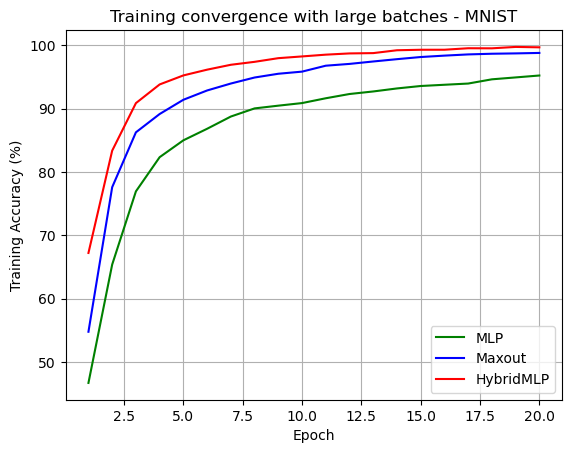

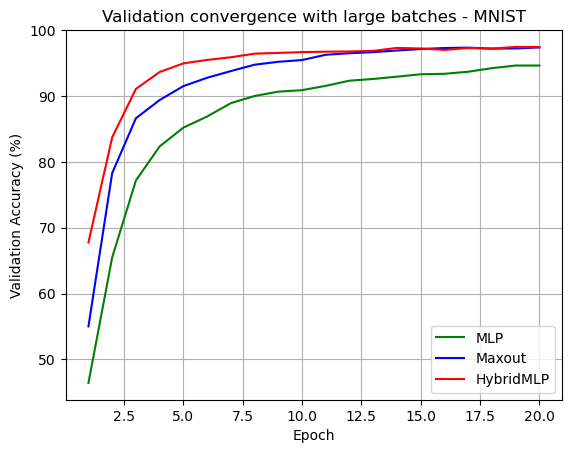

In [11]:
plt.figure()
plt.plot(np.arange(1,21), mlp_train_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_train_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_train_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Training convergence with large batches - MNIST')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.savefig("training_convergence_mnist_3.pdf", format='pdf', dpi=1000)
plt.show()

plt.figure()
plt.plot(np.arange(1,21), mlp_val_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_val_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_val_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Validation convergence with large batches - MNIST')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.savefig("validation_convergence_mnist_3.pdf", format='pdf', dpi=1000)
plt.show()

In [12]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [13]:
# Initialize model, loss function, and optimizer
model = MLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, mlp_train_list, mlp_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 466698
Epoch [1/20], Loss: 1.7511, Train Accuracy: 44.91%, Validation Accuracy: 44.97%
Epoch [2/20], Loss: 1.0501, Train Accuracy: 58.31%, Validation Accuracy: 58.67%
Epoch [3/20], Loss: 0.7845, Train Accuracy: 68.48%, Validation Accuracy: 68.23%
Epoch [4/20], Loss: 0.7119, Train Accuracy: 73.59%, Validation Accuracy: 73.57%
Epoch [5/20], Loss: 0.6364, Train Accuracy: 75.86%, Validation Accuracy: 75.81%
Epoch [6/20], Loss: 0.6016, Train Accuracy: 77.72%, Validation Accuracy: 77.96%
Epoch [7/20], Loss: 0.5691, Train Accuracy: 80.12%, Validation Accuracy: 80.38%
Epoch [8/20], Loss: 0.4942, Train Accuracy: 81.26%, Validation Accuracy: 81.33%
Epoch [9/20], Loss: 0.4787, Train Accuracy: 82.78%, Validation Accuracy: 82.86%
Epoch [10/20], Loss: 0.4748, Train Accuracy: 83.07%, Validation Accuracy: 82.81%
Epoch [11/20], Loss: 0.4472, Train Accuracy: 83.55%, Validation Accuracy: 83.33%
Epoch [12/20], Loss: 0.4128, Train Accuracy: 84.58%, Validation Accuracy: 84.25%
Ep

In [14]:
# Initialize model, loss function, and optimizer
model = Maxout(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, maxout_train_list, maxout_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 930826
Epoch [1/20], Loss: 0.9891, Train Accuracy: 60.13%, Validation Accuracy: 60.75%
Epoch [2/20], Loss: 0.6937, Train Accuracy: 74.00%, Validation Accuracy: 73.98%
Epoch [3/20], Loss: 0.5787, Train Accuracy: 78.04%, Validation Accuracy: 78.22%
Epoch [4/20], Loss: 0.5224, Train Accuracy: 78.21%, Validation Accuracy: 78.26%
Epoch [5/20], Loss: 0.4711, Train Accuracy: 81.48%, Validation Accuracy: 81.66%
Epoch [6/20], Loss: 0.4364, Train Accuracy: 83.81%, Validation Accuracy: 83.83%
Epoch [7/20], Loss: 0.4336, Train Accuracy: 84.80%, Validation Accuracy: 84.92%
Epoch [8/20], Loss: 0.3754, Train Accuracy: 86.13%, Validation Accuracy: 85.95%
Epoch [9/20], Loss: 0.3845, Train Accuracy: 86.20%, Validation Accuracy: 85.66%
Epoch [10/20], Loss: 0.3575, Train Accuracy: 87.00%, Validation Accuracy: 86.64%
Epoch [11/20], Loss: 0.3556, Train Accuracy: 87.59%, Validation Accuracy: 86.85%
Epoch [12/20], Loss: 0.3466, Train Accuracy: 87.69%, Validation Accuracy: 87.03%
Ep

In [15]:
# Initialize model, loss function, and optimizer
model = HybridMLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, hybrid_train_list, hybrid_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 796938


Epoch [1/20], Loss: 1.0417, Train Accuracy: 72.82%, Validation Accuracy: 72.88%
Epoch [2/20], Loss: 0.5974, Train Accuracy: 79.89%, Validation Accuracy: 79.86%
Epoch [3/20], Loss: 0.4383, Train Accuracy: 83.45%, Validation Accuracy: 83.47%
Epoch [4/20], Loss: 0.4178, Train Accuracy: 85.70%, Validation Accuracy: 85.37%
Epoch [5/20], Loss: 0.3586, Train Accuracy: 86.58%, Validation Accuracy: 85.97%
Epoch [6/20], Loss: 0.3147, Train Accuracy: 87.55%, Validation Accuracy: 86.40%
Epoch [7/20], Loss: 0.3298, Train Accuracy: 88.96%, Validation Accuracy: 87.54%
Epoch [8/20], Loss: 0.2889, Train Accuracy: 89.28%, Validation Accuracy: 87.62%
Epoch [9/20], Loss: 0.2824, Train Accuracy: 90.10%, Validation Accuracy: 87.85%
Epoch [10/20], Loss: 0.2399, Train Accuracy: 90.49%, Validation Accuracy: 88.28%
Epoch [11/20], Loss: 0.2335, Train Accuracy: 90.64%, Validation Accuracy: 88.31%
Epoch [12/20], Loss: 0.2483, Train Accuracy: 91.35%, Validation Accuracy: 88.44%
Epoch [13/20], Loss: 0.2639, Train Ac

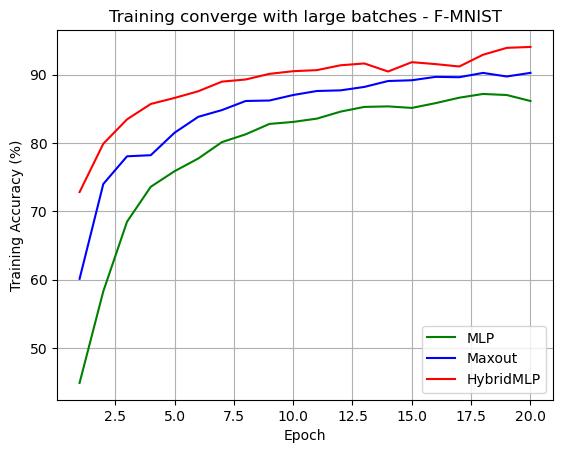

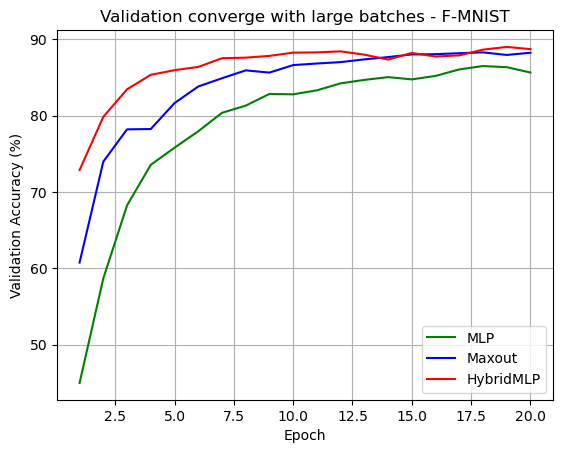

In [16]:
plt.figure()
plt.plot(np.arange(1,21), mlp_train_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_train_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_train_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Training converge with large batches - F-MNIST')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.savefig("training_convergence_fashion_mnist_3.pdf", format='pdf', dpi=1000)
plt.show()

plt.figure()
plt.plot(np.arange(1,21), mlp_val_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_val_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_val_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Validation converge with large batches - F-MNIST')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.savefig("validation_convergence_fashion_mnist_3.pdf", format='pdf', dpi=1000)
plt.show()

In [17]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [18]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 2.7022, Train Accuracy: 11.59%, Validation Accuracy: 11.03%
Epoch [2/50], Loss: 2.0800, Train Accuracy: 14.86%, Validation Accuracy: 14.82%
Epoch [3/50], Loss: 2.1086, Train Accuracy: 23.07%, Validation Accuracy: 22.79%
Epoch [4/50], Loss: 1.9719, Train Accuracy: 24.66%, Validation Accuracy: 24.45%
Epoch [5/50], Loss: 1.9960, Train Accuracy: 18.41%, Validation Accuracy: 17.87%
Epoch [6/50], Loss: 1.7183, Train Accuracy: 25.71%, Validation Accuracy: 25.44%
Epoch [7/50], Loss: 1.5752, Train Accuracy: 27.77%, Validation Accuracy: 27.65%
Epoch [8/50], Loss: 2.2986, Train Accuracy: 11.29%, Validation Accuracy: 11.47%
Epoch [9/50], Loss: 2.1346, Train Accuracy: 14.31%, Validation Accuracy: 14.61%
Epoch [10/50], Loss: 2.4056, Train Accuracy: 15.16%, Validation Accuracy: 15.18%
Epoch [11/50], Loss: 2.3642, Train Accuracy: 15.67%, Validation Accuracy: 15.17%
Epoch [12/50], Loss: 2.1819, Train Accuracy: 17.50%, Validation Accuracy: 16.81%
Ep

In [19]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 29.75%


In [20]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=640, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [21]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 0.2296, Train Accuracy: 93.84%, Validation Accuracy: 93.40%
Epoch [2/50], Loss: 0.1731, Train Accuracy: 94.68%, Validation Accuracy: 93.97%
Epoch [3/50], Loss: 0.1641, Train Accuracy: 95.92%, Validation Accuracy: 95.06%
Epoch [4/50], Loss: 0.1380, Train Accuracy: 96.61%, Validation Accuracy: 95.82%
Epoch [5/50], Loss: 0.1017, Train Accuracy: 97.47%, Validation Accuracy: 96.31%
Epoch [6/50], Loss: 0.1068, Train Accuracy: 97.37%, Validation Accuracy: 96.33%
Epoch [7/50], Loss: 0.0784, Train Accuracy: 97.32%, Validation Accuracy: 96.00%
Epoch [8/50], Loss: 0.0926, Train Accuracy: 97.89%, Validation Accuracy: 96.67%
Epoch [9/50], Loss: 0.0736, Train Accuracy: 98.11%, Validation Accuracy: 96.71%
Epoch [10/50], Loss: 0.0695, Train Accuracy: 97.81%, Validation Accuracy: 96.50%
Epoch [11/50], Loss: 0.1193, Train Accuracy: 96.99%, Validation Accuracy: 95.42%
Epoch [12/50], Loss: 0.0729, Train Accuracy: 97.86%, Validation Accuracy: 96.19%
Ep

In [22]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 96.82%


In [23]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [24]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 1.5382, Train Accuracy: 57.34%, Validation Accuracy: 57.61%
Epoch [2/50], Loss: 0.7376, Train Accuracy: 83.23%, Validation Accuracy: 83.03%
Epoch [3/50], Loss: 0.3549, Train Accuracy: 90.40%, Validation Accuracy: 90.33%
Epoch [4/50], Loss: 0.2520, Train Accuracy: 93.23%, Validation Accuracy: 93.24%
Epoch [5/50], Loss: 0.1942, Train Accuracy: 94.87%, Validation Accuracy: 94.76%
Epoch [6/50], Loss: 0.1577, Train Accuracy: 96.10%, Validation Accuracy: 95.45%
Epoch [7/50], Loss: 0.1232, Train Accuracy: 96.83%, Validation Accuracy: 96.08%
Epoch [8/50], Loss: 0.0875, Train Accuracy: 97.60%, Validation Accuracy: 96.35%
Epoch [9/50], Loss: 0.0892, Train Accuracy: 98.06%, Validation Accuracy: 96.69%
Epoch [10/50], Loss: 0.0822, Train Accuracy: 98.34%, Validation Accuracy: 96.88%
Epoch [11/50], Loss: 0.0542, Train Accuracy: 97.84%, Validation Accuracy: 96.21%
Epoch [12/50], Loss: 0.0452, Train Accuracy: 98.70%, Validation Accuracy: 96.92%
Ep

In [25]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.51%


In [26]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [27]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 35.0490, Train Accuracy: 11.64%, Validation Accuracy: 12.04%
Epoch [2/50], Loss: 2.2237, Train Accuracy: 14.05%, Validation Accuracy: 13.93%
Epoch [3/50], Loss: 2.2289, Train Accuracy: 22.76%, Validation Accuracy: 22.82%
Epoch [4/50], Loss: 2.0162, Train Accuracy: 22.95%, Validation Accuracy: 22.82%
Epoch [5/50], Loss: 1.9175, Train Accuracy: 24.26%, Validation Accuracy: 23.71%
Epoch [6/50], Loss: 1.8216, Train Accuracy: 22.45%, Validation Accuracy: 22.22%
Epoch [7/50], Loss: 2.4145, Train Accuracy: 6.05%, Validation Accuracy: 5.80%
Epoch [8/50], Loss: 2.1997, Train Accuracy: 12.56%, Validation Accuracy: 12.17%
Epoch [9/50], Loss: 2.0595, Train Accuracy: 17.80%, Validation Accuracy: 17.59%
Epoch [10/50], Loss: 2.1150, Train Accuracy: 18.91%, Validation Accuracy: 18.93%
Epoch [11/50], Loss: 2.1735, Train Accuracy: 18.64%, Validation Accuracy: 18.43%
Epoch [12/50], Loss: 2.1424, Train Accuracy: 18.94%, Validation Accuracy: 18.77%
Epo

In [28]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 31.71%


In [29]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=640, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [30]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938


Epoch [1/50], Loss: 0.4422, Train Accuracy: 84.29%, Validation Accuracy: 83.37%
Epoch [2/50], Loss: 0.3799, Train Accuracy: 86.72%, Validation Accuracy: 85.62%
Epoch [3/50], Loss: 0.3349, Train Accuracy: 87.35%, Validation Accuracy: 86.12%
Epoch [4/50], Loss: 0.3604, Train Accuracy: 88.56%, Validation Accuracy: 86.78%
Epoch [5/50], Loss: 0.2649, Train Accuracy: 86.99%, Validation Accuracy: 85.16%
Epoch [6/50], Loss: 0.3148, Train Accuracy: 89.21%, Validation Accuracy: 87.39%
Epoch [7/50], Loss: 0.2689, Train Accuracy: 89.68%, Validation Accuracy: 87.51%
Epoch [8/50], Loss: 0.3211, Train Accuracy: 90.54%, Validation Accuracy: 87.86%
Epoch [9/50], Loss: 0.3036, Train Accuracy: 90.11%, Validation Accuracy: 87.45%
Epoch [10/50], Loss: 0.2943, Train Accuracy: 90.35%, Validation Accuracy: 87.69%
Epoch [11/50], Loss: 0.2572, Train Accuracy: 91.42%, Validation Accuracy: 88.43%
Epoch [12/50], Loss: 0.2228, Train Accuracy: 91.53%, Validation Accuracy: 88.19%
Epoch [13/50], Loss: 0.2923, Train Ac

In [31]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 87.55%


In [32]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [33]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938


Epoch [1/50], Loss: 1.1153, Train Accuracy: 70.57%, Validation Accuracy: 69.48%
Epoch [2/50], Loss: 0.6553, Train Accuracy: 78.85%, Validation Accuracy: 78.04%
Epoch [3/50], Loss: 0.5257, Train Accuracy: 83.11%, Validation Accuracy: 82.22%
Epoch [4/50], Loss: 0.4414, Train Accuracy: 84.21%, Validation Accuracy: 83.12%
Epoch [5/50], Loss: 0.4102, Train Accuracy: 85.75%, Validation Accuracy: 84.22%
Epoch [6/50], Loss: 0.3514, Train Accuracy: 86.95%, Validation Accuracy: 85.64%
Epoch [7/50], Loss: 0.3590, Train Accuracy: 87.87%, Validation Accuracy: 86.15%
Epoch [8/50], Loss: 0.3265, Train Accuracy: 88.92%, Validation Accuracy: 86.61%
Epoch [9/50], Loss: 0.3203, Train Accuracy: 88.90%, Validation Accuracy: 86.89%
Epoch [10/50], Loss: 0.2850, Train Accuracy: 90.42%, Validation Accuracy: 87.53%
Epoch [11/50], Loss: 0.2710, Train Accuracy: 90.83%, Validation Accuracy: 87.72%
Epoch [12/50], Loss: 0.2439, Train Accuracy: 91.31%, Validation Accuracy: 88.14%
Epoch [13/50], Loss: 0.2370, Train Ac

In [34]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 87.93%


### Compression experiments

In [35]:
def prune_weightsMLP(model, pruning_ratio=0.2):
    model = copy.deepcopy(model)  # Clone model to avoid modifying the original

    def prune_layer(layer):
        """Zero out the smallest magnitude weights in 'layer'."""
        with torch.no_grad():
            weight = layer.weight.data
            num_to_prune = int(pruning_ratio * weight.numel())

            # Get absolute values and sort
            flat_weights = weight.abs().flatten()
            threshold = torch.topk(flat_weights, num_to_prune, largest=False).values.max()

            # Zero out weights below the threshold
            weight[weight.abs() <= threshold] = 0.0

    # Apply pruning to all linear layers in the model
    prune_layer(model.fc1)
    for layer in model.fcs:
        prune_layer(layer)
    prune_layer(model.fc2)

    return model  # Return the pruned model

def prune_weightsMPM(model, pruning_ratio=0.2):
    model = copy.deepcopy(model)  # Clone model to avoid modifying the original

    def prune_layer(layer):
        morph_layer, linact = layer[0], layer[1]
        """Zero out the smallest magnitude weights in 'layer'."""
        with torch.no_grad():
            w = morph_layer.w.data
            num_to_prune = int(pruning_ratio * w.numel())

            # Get absolute values and so
            flat_weights = w.abs().flatten()
            threshold = torch.topk(flat_weights, num_to_prune, largest=False).values.max()

            # Zero out weights below the threshold
            w[w.abs() <= threshold] = 0.0

    # Apply pruning to all linear layers in the model
    prune_layer([model.morph_layer1, model.linact1])
    for layer in model.morph_layers:
        prune_layer(layer)
    prune_layer([model.morph_layer2, None])

    return model  # Return the pruned model

In [36]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [37]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 466698
Epoch [1/50], Loss: 0.2619, Train Accuracy: 91.03%, Validation Accuracy: 90.97%
Epoch [2/50], Loss: 0.1736, Train Accuracy: 94.51%, Validation Accuracy: 93.98%
Epoch [3/50], Loss: 0.1102, Train Accuracy: 96.52%, Validation Accuracy: 95.78%
Epoch [4/50], Loss: 0.0926, Train Accuracy: 96.73%, Validation Accuracy: 95.99%
Epoch [5/50], Loss: 0.1190, Train Accuracy: 97.39%, Validation Accuracy: 96.46%
Epoch [6/50], Loss: 0.0223, Train Accuracy: 97.57%, Validation Accuracy: 96.63%
Epoch [7/50], Loss: 0.0286, Train Accuracy: 97.61%, Validation Accuracy: 96.60%
Epoch [8/50], Loss: 0.0485, Train Accuracy: 98.22%, Validation Accuracy: 96.93%
Epoch [9/50], Loss: 0.0099, Train Accuracy: 98.46%, Validation Accuracy: 97.16%
Epoch [10/50], Loss: 0.0395, Train Accuracy: 99.02%, Validation Accuracy: 97.59%
Epoch [11/50], Loss: 0.0249, Train Accuracy: 98.65%, Validation Accuracy: 97.40%
Epoch [12/50], Loss: 0.0069, Train Accuracy: 98.59%, Validation Accuracy: 97.09%
Ep

In [38]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 98.00%


In [39]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMLP(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85


Accuracy on the test set: 66.22%
Pruning ratio: 0.875
Accuracy on the test set: 53.25%
Pruning ratio: 0.9
Accuracy on the test set: 45.77%
Pruning ratio: 0.925
Accuracy on the test set: 19.76%
Pruning ratio: 0.95
Accuracy on the test set: 10.39%
Pruning ratio: 0.975
Accuracy on the test set: 10.23%


In [40]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.6983, Train Accuracy: 84.35%, Validation Accuracy: 84.09%
Epoch [2/50], Loss: 0.5283, Train Accuracy: 90.10%, Validation Accuracy: 89.31%
Epoch [3/50], Loss: 0.5046, Train Accuracy: 92.19%, Validation Accuracy: 91.16%
Epoch [4/50], Loss: 0.1246, Train Accuracy: 93.40%, Validation Accuracy: 92.04%
Epoch [5/50], Loss: 0.2547, Train Accuracy: 94.07%, Validation Accuracy: 92.42%
Epoch [6/50], Loss: 0.2126, Train Accuracy: 94.77%, Validation Accuracy: 92.91%
Epoch [7/50], Loss: 0.1729, Train Accuracy: 95.20%, Validation Accuracy: 93.12%
Epoch [8/50], Loss: 0.2231, Train Accuracy: 95.51%, Validation Accuracy: 93.19%
Epoch [9/50], Loss: 0.0907, Train Accuracy: 95.99%, Validation Accuracy: 93.62%
Epoch [10/50], Loss: 0.1823, Train Accuracy: 96.50%, Validation Accuracy: 93.73%
Epoch [11/50], Loss: 0.1771, Train Accuracy: 96.81%, Validation Accuracy: 93.83%
Epoch [12/50], Loss: 0.0794, Train Accuracy: 96.95%, Validation Accuracy: 93.91%
Ep

In [41]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 93.84%


In [42]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMPM(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85


Accuracy on the test set: 92.75%
Pruning ratio: 0.875
Accuracy on the test set: 92.35%
Pruning ratio: 0.9
Accuracy on the test set: 91.57%
Pruning ratio: 0.925
Accuracy on the test set: 90.81%
Pruning ratio: 0.95
Accuracy on the test set: 86.62%
Pruning ratio: 0.975
Accuracy on the test set: 77.88%


In [43]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [44]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 466698
Epoch [1/50], Loss: 0.3124, Train Accuracy: 84.54%, Validation Accuracy: 83.75%
Epoch [2/50], Loss: 0.5436, Train Accuracy: 86.65%, Validation Accuracy: 85.70%
Epoch [3/50], Loss: 0.3311, Train Accuracy: 87.85%, Validation Accuracy: 86.65%
Epoch [4/50], Loss: 0.4157, Train Accuracy: 88.38%, Validation Accuracy: 85.96%
Epoch [5/50], Loss: 0.1569, Train Accuracy: 87.64%, Validation Accuracy: 86.37%
Epoch [6/50], Loss: 0.3764, Train Accuracy: 89.41%, Validation Accuracy: 87.17%
Epoch [7/50], Loss: 0.4484, Train Accuracy: 89.05%, Validation Accuracy: 87.04%
Epoch [8/50], Loss: 0.4383, Train Accuracy: 90.46%, Validation Accuracy: 87.73%
Epoch [9/50], Loss: 0.1181, Train Accuracy: 90.26%, Validation Accuracy: 87.29%
Epoch [10/50], Loss: 0.2326, Train Accuracy: 91.30%, Validation Accuracy: 87.95%
Epoch [11/50], Loss: 0.3438, Train Accuracy: 91.86%, Validation Accuracy: 88.28%
Epoch [12/50], Loss: 0.2555, Train Accuracy: 91.93%, Validation Accuracy: 88.96%
Ep

In [45]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 88.60%


In [46]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMLP(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85
Accuracy on the test set: 60.12%
Pruning ratio: 0.875
Accuracy on the test set: 41.97%
Pruning ratio: 0.9
Accuracy on the test set: 19.31%
Pruning ratio: 0.925
Accuracy on the test set: 13.43%
Pruning ratio: 0.95
Accuracy on the test set: 9.73%
Pruning ratio: 0.975
Accuracy on the test set: 10.48%


In [47]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.9871, Train Accuracy: 76.41%, Validation Accuracy: 75.10%
Epoch [2/50], Loss: 0.5023, Train Accuracy: 83.21%, Validation Accuracy: 80.92%
Epoch [3/50], Loss: 0.3136, Train Accuracy: 85.85%, Validation Accuracy: 82.52%
Epoch [4/50], Loss: 0.3460, Train Accuracy: 87.47%, Validation Accuracy: 82.95%
Epoch [5/50], Loss: 0.4023, Train Accuracy: 88.76%, Validation Accuracy: 83.12%
Epoch [6/50], Loss: 0.4071, Train Accuracy: 89.64%, Validation Accuracy: 83.37%
Epoch [7/50], Loss: 0.3076, Train Accuracy: 90.64%, Validation Accuracy: 83.86%
Epoch [8/50], Loss: 0.2791, Train Accuracy: 91.38%, Validation Accuracy: 83.51%
Epoch [9/50], Loss: 0.3649, Train Accuracy: 92.10%, Validation Accuracy: 83.51%
Epoch [10/50], Loss: 0.3281, Train Accuracy: 92.75%, Validation Accuracy: 83.80%
Epoch [11/50], Loss: 0.4170, Train Accuracy: 93.17%, Validation Accuracy: 83.53%
Epoch [12/50], Loss: 0.2708, Train Accuracy: 93.50%, Validation Accuracy: 83.50%
Ep

In [48]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 83.03%


In [49]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMPM(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85
Accuracy on the test set: 81.76%
Pruning ratio: 0.875
Accuracy on the test set: 79.03%
Pruning ratio: 0.9
Accuracy on the test set: 78.73%
Pruning ratio: 0.925
Accuracy on the test set: 78.12%
Pruning ratio: 0.95
Accuracy on the test set: 74.89%
Pruning ratio: 0.975
Accuracy on the test set: 51.53%
